# 32 — Conservation Gap Analysis

Aggregate the per-species current flows (from notebook 31) and GNN suitability
scores into a multi-species priority surface, then overlay with Swiss protected
areas to quantify conservation gaps.

**Decisions made here**:
- How to normalise raw current flow per species (max vs p99 vs rank)
- How to weight species (equal vs IUCN-weighted)
- How to combine suitability and connectivity into a priority score

**Pipeline**:
1. Load current flows + suitability from notebooks 31 / GNN output
2. Choose normalisation strategy
3. Aggregate into a multi-species priority surface
4. Overlay with WDPA protected areas
5. Quantify: what fraction of high-priority patches are protected?

### Setup

In [1]:
import config
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt

with open('landscape_graph.pkl', 'rb') as f:
    G = pickle.load(f)

n_patches = G.number_of_nodes()
print(f'Graph: {n_patches:,} nodes, {G.number_of_edges():,} edges')

# Load current flows from notebook 31
current_npz = np.load('gap_analysis_output/current_flows.npz')
species_summary = pd.read_csv('gap_analysis_output/species_summary.csv')

# Load suitability scores
scores_npz = np.load('gnn_training_output/suitability_scores.npz')

SPECIES = species_summary['species'].tolist()
print(f'Species for gap analysis: {len(SPECIES)}')
print(f'Current flow arrays: {len(current_npz.files)}')

Graph: 166,464 nodes, 465,833 edges
Species for gap analysis: 12
Current flow arrays: 12


### Normalisation and aggregation

**Normalisation**: Per-species current is normalised to [0, 1] using the
99th percentile as the ceiling (values above p99 are clipped to 1).
This is more robust than max-normalisation since a single extreme
pinch-point won't compress all other values toward zero.

**Species weighting**: IUCN threat-level weights (EN=3, VU=2, NT=1).
More threatened species contribute proportionally more to the priority
surface, reflecting their greater conservation urgency.

**Priority score**: `(weighted_mean_suitability + weighted_mean_current) / 2`
— equal weight to habitat quality and connectivity.

In [2]:
# IUCN threat-level weights
IUCN_WEIGHTS = {
    'CRITICALLY_ENDANGERED': 4,
    'ENDANGERED': 3,
    'VULNERABLE': 2,
    'NEAR_THREATENED': 1,
}

all_suitability = np.zeros(n_patches, dtype=np.float64)
all_current = np.zeros(n_patches, dtype=np.float64)
total_weight = 0.0

for sp in SPECIES:
    key = sp.replace(' ', '_')

    # Suitability
    if key not in scores_npz.files:
        print(f'  WARNING: no suitability for {sp}, skipping')
        continue
    suit = scores_npz[key]

    # Current flow
    if key not in current_npz.files:
        print(f'  WARNING: no current flow for {sp}, skipping')
        continue
    current = current_npz[key]

    # Normalise current: p99-based clipping to [0, 1]
    nonzero = current[current > 0]
    if len(nonzero) == 0:
        print(f'  WARNING: {sp} has zero current everywhere, skipping')
        continue
    p99 = np.percentile(nonzero, 99)
    if p99 > 0:
        current_norm = np.clip(current / p99, 0, 1)
    else:
        current_norm = np.zeros_like(current)

    # Get IUCN weight for this species
    cat = species_summary[species_summary['species'] == sp]['iucn_category'].values[0]
    w = IUCN_WEIGHTS.get(cat, 1)

    all_suitability += suit * w
    all_current += current_norm * w
    total_weight += w
    print(f'  {sp} [{cat[:2]}] weight={w}')

# Weighted average across species
mean_suitability = all_suitability / total_weight
mean_current = all_current / total_weight

# Combined priority score
priority_score = (mean_suitability + mean_current) / 2

print(f'\nSpecies included: {int(total_weight)} weight-units from {len(SPECIES)} species')
print(f'Mean suitability: {mean_suitability.mean():.4f} (max {mean_suitability.max():.4f})')
print(f'Mean current:     {mean_current.mean():.4f} (max {mean_current.max():.4f})')
print(f'Priority score:   {priority_score.mean():.4f} (max {priority_score.max():.4f})')

  Baldellia ranunculoides [NE] weight=1
  Eryngium alpinum [NE] weight=1
  Fraxinus excelsior [NE] weight=1
  Frullania jackii [VU] weight=2
  Galanthus nivalis [NE] weight=1
  Gentiana pannonica [NE] weight=1
  Jacobaea uniflora [NE] weight=1
  Poa laxa [EN] weight=3
  Poterium dodecandrum [NE] weight=1
  Pulsatilla vulgaris [NE] weight=1
  Riccia breidleri [VU] weight=2
  Trifolium saxatile [NE] weight=1

Species included: 16 weight-units from 12 species
Mean suitability: 0.0763 (max 0.6832)
Mean current:     0.0419 (max 0.9185)
Priority score:   0.0591 (max 0.8009)


### Overlay with protected areas

IUCN Protected Area Management Categories differ substantially in protection
strength. We split into two tiers:

- **Strict protection** (Ia, Ib, II, III): areas managed primarily for
  biodiversity conservation with minimal human use.
- **Managed protection** (IV, V, VI): areas allowing increasing levels of
  human use and management intervention.

Sites with `Not Assigned` or `Not Reported` categories are excluded from
the strict tier but included in an overall 'any protection' set.

This distinction matters because a Category V 'Protected Landscape' permits
agriculture and settlement, offering far weaker habitat safeguards than a
Category Ia strict nature reserve.

In [3]:
import geopandas as gpd
import rioxarray
from s3_utils import load_zarr
from rasterio.features import rasterize
from rasterio.transform import from_bounds

# Load protected areas
pa = gpd.read_file('protected_areas_ch.geojson')
print(f'Protected areas: {len(pa)}')
print(f'Categories: {pa["iucn_cat"].value_counts().to_dict()}')

# Define protection tiers
STRICT_CATEGORIES = {'Ia', 'Ib', 'II', 'III'}
MANAGED_CATEGORIES = {'IV', 'V', 'VI'}
# 'Not Assigned' and 'Not Reported' go into 'any' but not strict/managed

pa_strict = pa[pa['iucn_cat'].isin(STRICT_CATEGORIES)]
pa_managed = pa[pa['iucn_cat'].isin(MANAGED_CATEGORIES)]
print(f'\nStrict protection (Ia–III): {len(pa_strict):,} areas')
print(f'Managed protection (IV–VI): {len(pa_managed):,} areas')
print(f'Unclassified (Not Assigned/Not Reported): {len(pa) - len(pa_strict) - len(pa_managed):,} areas')

# Load patch labels raster
patch_labels_da = load_zarr(
    config.S3_PROCESSED + '/patches/patch_labels_30m.zarr',
    name='patch_label',
)
patch_labels = patch_labels_da.values
h, w = patch_labels.shape
bounds = patch_labels_da.rio.bounds()
raster_transform = from_bounds(bounds[0], bounds[1], bounds[2], bounds[3], w, h)

# Helper: rasterise a subset of PA polygons and compute patch-level overlap
def pa_to_patch_set(pa_subset):
    shapes = [(geom, 1) for geom in pa_subset.geometry if geom is not None]
    if not shapes:
        return set()
    mask = rasterize(
        shapes, out_shape=(h, w), transform=raster_transform,
        fill=0, dtype=np.uint8
    )
    flat = mask[valid].astype(np.float64)
    overlap_sum = np.bincount(patch_ids_flat, weights=flat, minlength=n_patches)
    frac = np.zeros(n_patches)
    frac[nonzero_mask] = overlap_sum[nonzero_mask] / total_count[nonzero_mask]
    return set(np.where(frac > 0.0)[0])

# Compute patch-level counts (shared across all tiers)
valid = patch_labels >= 0
patch_ids_flat = patch_labels[valid].astype(np.int64)
total_count = np.bincount(patch_ids_flat, minlength=n_patches)
nonzero_mask = total_count > 0

# Compute per-tier patch sets
strict_patches = pa_to_patch_set(pa_strict)
managed_patches = pa_to_patch_set(pa_managed)
# 'Any protection' = all PA polygons (including unclassified)
protected_patches = pa_to_patch_set(pa)

print(f'\nPatch coverage (before Swiss-only filter):')
print(f'  Strict (Ia–III):   {len(strict_patches):,} / {n_patches:,} ({len(strict_patches)/n_patches*100:.1f}%)')
print(f'  Managed (IV–VI):   {len(managed_patches):,} / {n_patches:,} ({len(managed_patches)/n_patches*100:.1f}%)')
print(f'  Any protection:    {len(protected_patches):,} / {n_patches:,} ({len(protected_patches)/n_patches*100:.1f}%)')

Protected areas: 10522
Categories: {'IV': 6629, 'Not Assigned': 3302, 'Ia': 553, 'Not Reported': 37, 'VI': 1}

Strict protection (Ia–III): 553 areas
Managed protection (IV–VI): 6,630 areas
Unclassified (Not Assigned/Not Reported): 3,339 areas

Patch coverage (before Swiss-only filter):
  Strict (Ia–III):   1,092 / 166,464 (0.7%)
  Managed (IV–VI):   14,145 / 166,464 (8.5%)
  Any protection:    18,948 / 166,464 (11.4%)


### Restrict to Switzerland

In [4]:
# Load Switzerland boundary
ch_boundary = gpd.read_file('switzerland_boundary.geojson')
ch_shapes = [(geom, 1) for geom in ch_boundary.geometry if geom is not None]
ch_mask = rasterize(
    ch_shapes, out_shape=(h, w), transform=raster_transform,
    fill=0, dtype=np.uint8
)

ch_flat = ch_mask[valid].astype(np.float64)
ch_sum = np.bincount(patch_ids_flat, weights=ch_flat, minlength=n_patches)
frac_in_ch = np.zeros(n_patches)
frac_in_ch[nonzero_mask] = ch_sum[nonzero_mask] / total_count[nonzero_mask]

swiss_patches = set(np.where(frac_in_ch > 0.5)[0])
n_swiss = len(swiss_patches)
print(f'Swiss patches: {n_swiss:,} / {n_patches:,} ({n_swiss/n_patches*100:.1f}%)')

# Restrict all protection sets to Swiss patches
strict_patches = strict_patches & swiss_patches
managed_patches = managed_patches & swiss_patches
protected_patches = protected_patches & swiss_patches

print(f'\nSwiss protection coverage:')
print(f'  Strict (Ia–III):   {len(strict_patches):,} / {n_swiss:,} ({len(strict_patches)/n_swiss*100:.1f}%)')
print(f'  Managed (IV–VI):   {len(managed_patches):,} / {n_swiss:,} ({len(managed_patches)/n_swiss*100:.1f}%)')
print(f'  Any protection:    {len(protected_patches):,} / {n_swiss:,} ({len(protected_patches)/n_swiss*100:.1f}%)')
print(f'  Unprotected:       {n_swiss - len(protected_patches):,} / {n_swiss:,} ({(n_swiss - len(protected_patches))/n_swiss*100:.1f}%)')

Swiss patches: 65,298 / 166,464 (39.2%)

Swiss protection coverage:
  Strict (Ia–III):   1,081 / 65,298 (1.7%)
  Managed (IV–VI):   13,965 / 65,298 (21.4%)
  Any protection:    18,695 / 65,298 (28.6%)
  Unprotected:       46,603 / 65,298 (71.4%)


### Analysis 1: Protection effectiveness

Compare IUCN-weighted mean habitat suitability across protection tiers.
Ratio > 1 means the tier covers better-than-average habitat for threatened species.

We report separately for strict (Ia–III), managed (IV–VI), and unprotected patches.

In [5]:
strict_arr = np.array(list(strict_patches))
managed_arr = np.array(list(managed_patches))
protected_arr = np.array(list(protected_patches))
unprotected_arr = np.array(list(swiss_patches - protected_patches))

print('=== Analysis 1: Protection Effectiveness (Switzerland only) ===')
print(f'Strict (Ia–III):  {len(strict_arr):,} patches ({len(strict_arr)/n_swiss*100:.1f}%)')
print(f'Managed (IV–VI):  {len(managed_arr):,} patches ({len(managed_arr)/n_swiss*100:.1f}%)')
print(f'Any protection:   {len(protected_arr):,} patches ({len(protected_arr)/n_swiss*100:.1f}%)')
print(f'Unprotected:      {len(unprotected_arr):,} patches ({len(unprotected_arr)/n_swiss*100:.1f}%)')

print(f'\n{"Species":30s} {"IUCN":>5s} {"Strict":>8s} {"Managed":>9s} {"Unprot":>8s} {"Strict/Unprot":>14s}')
print('-' * 80)

for sp in SPECIES:
    key = sp.replace(' ', '_')
    if key not in scores_npz.files:
        continue
    suit = scores_npz[key]
    cat = species_summary[species_summary['species'] == sp]['iucn_category'].values[0]
    cat_short = {'CRITICALLY_ENDANGERED': 'CR', 'ENDANGERED': 'EN',
                 'VULNERABLE': 'VU', 'NEAR_THREATENED': 'NT'}.get(cat, '?')
    s_strict = suit[strict_arr].mean() if len(strict_arr) > 0 else 0
    s_managed = suit[managed_arr].mean() if len(managed_arr) > 0 else 0
    s_out = suit[unprotected_arr].mean()
    ratio = s_strict / max(s_out, 1e-8)
    print(f'{sp:30s} {cat_short:>5s} {s_strict:>8.4f} {s_managed:>9.4f} {s_out:>8.4f} {ratio:>12.2f}x')

# Aggregate
s_strict_all = mean_suitability[strict_arr].mean() if len(strict_arr) > 0 else 0
s_managed_all = mean_suitability[managed_arr].mean() if len(managed_arr) > 0 else 0
s_out_all = mean_suitability[unprotected_arr].mean()
print(f'{"--- MEAN ---":30s} {"":>5s} {s_strict_all:>8.4f} {s_managed_all:>9.4f} {s_out_all:>8.4f} {s_strict_all/max(s_out_all,1e-8):>12.2f}x')
print(f'\nInterpretation: Strict PAs are {s_strict_all/max(s_out_all,1e-8):.2f}x better habitat on average.')
print(f'Managed PAs are {s_managed_all/max(s_out_all,1e-8):.2f}x vs unprotected.')

=== Analysis 1: Protection Effectiveness (Switzerland only) ===
Strict (Ia–III):  1,081 patches (1.7%)
Managed (IV–VI):  13,965 patches (21.4%)
Any protection:   18,695 patches (28.6%)
Unprotected:      46,603 patches (71.4%)

Species                         IUCN   Strict   Managed   Unprot  Strict/Unprot
--------------------------------------------------------------------------------
Baldellia ranunculoides           NT   0.0166    0.0755   0.1019         0.16x
Eryngium alpinum                  NT   0.2175    0.2089   0.0985         2.21x
Fraxinus excelsior                NT   0.1760    0.1662   0.1078         1.63x
Frullania jackii                  VU   0.1824    0.1508   0.0806         2.26x
Galanthus nivalis                 NT   0.1617    0.1737   0.1578         1.02x
Gentiana pannonica                NT   0.1627    0.1642   0.1142         1.42x
Jacobaea uniflora                 NT   0.0263    0.0563   0.0487         0.54x
Poa laxa                          EN   0.0910    0.1312   0

### Analysis 2: Expansion priorities

High-connectivity patches that are currently unprotected = priority
candidates for new reserves. We also check how many high-connectivity
patches fall into managed (IV–VI) areas, since those provide weaker
guarantees and could benefit from upgraded protection status.

In [6]:
print('=== Analysis 2: Expansion Priorities (Switzerland only) ===')

swiss_arr = np.array(list(swiss_patches))
swiss_current = mean_current[swiss_arr]

# Top 10% connectivity
p90_current = np.percentile(swiss_current[swiss_current > 0], 90)
high_connectivity = set(np.where(mean_current >= p90_current)[0]) & swiss_patches

hc_strict = high_connectivity & strict_patches
hc_managed = high_connectivity & managed_patches
hc_protected = high_connectivity & protected_patches
hc_unprotected = high_connectivity - protected_patches

print(f'High-connectivity patches (top 10%): {len(high_connectivity):,}')
print(f'  Strictly protected (Ia–III): {len(hc_strict):,} ({len(hc_strict)/len(high_connectivity)*100:.1f}%)')
print(f'  Managed only (IV–VI):        {len(hc_managed - hc_strict):,} ({len(hc_managed - hc_strict)/len(high_connectivity)*100:.1f}%)')
print(f'  Any protection:              {len(hc_protected):,} ({len(hc_protected)/len(high_connectivity)*100:.1f}%)')
print(f'  UNPROTECTED:                 {len(hc_unprotected):,} ({len(hc_unprotected)/len(high_connectivity)*100:.1f}%)')

# Top 5% — critical corridors
p95_current = np.percentile(swiss_current[swiss_current > 0], 95)
critical_corridors = set(np.where(mean_current >= p95_current)[0]) & swiss_patches
cc_strict = critical_corridors & strict_patches
cc_managed = critical_corridors & managed_patches
cc_unprotected = critical_corridors - protected_patches

print(f'\nCritical corridor patches (top 5%): {len(critical_corridors):,}')
print(f'  Strictly protected: {len(cc_strict):,} ({len(cc_strict)/len(critical_corridors)*100:.1f}%)')
print(f'  Managed only:       {len(cc_managed - cc_strict):,} ({len(cc_managed - cc_strict)/len(critical_corridors)*100:.1f}%)')
print(f'  UNPROTECTED:        {len(cc_unprotected):,} ({len(cc_unprotected)/len(critical_corridors)*100:.1f}%)')

print(f'\nPriority actions:')
print(f'  1. {len(cc_unprotected):,} unprotected critical corridor patches → new protection needed')
print(f'  2. {len(cc_managed - cc_strict):,} managed-only critical corridor patches → consider upgrading to strict status')

=== Analysis 2: Expansion Priorities (Switzerland only) ===
High-connectivity patches (top 10%): 6,493
  Strictly protected (Ia–III): 246 (3.8%)
  Managed only (IV–VI):        2,528 (38.9%)
  Any protection:              3,203 (49.3%)
  UNPROTECTED:                 3,290 (50.7%)

Critical corridor patches (top 5%): 3,247
  Strictly protected: 157 (4.8%)
  Managed only:       1,366 (42.1%)
  UNPROTECTED:        1,551 (47.8%)

Priority actions:
  1. 1,551 unprotected critical corridor patches → new protection needed
  2. 1,366 managed-only critical corridor patches → consider upgrading to strict status


### Visualise priority surface

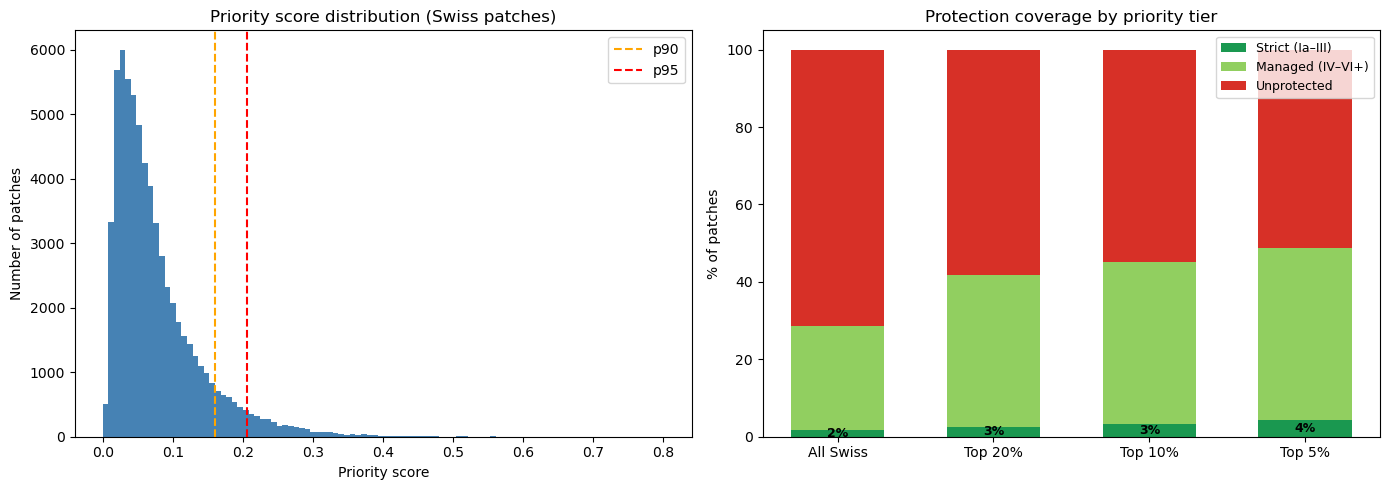

In [7]:
# Summary visualisation: priority score histogram + protection tiers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Priority score distribution
ax = axes[0]
swiss_priority = priority_score[swiss_arr]
ax.hist(swiss_priority[swiss_priority > 0], bins=100, color='steelblue', edgecolor='none')
ax.axvline(np.percentile(swiss_priority[swiss_priority > 0], 90), color='orange',
           linestyle='--', label='p90')
ax.axvline(np.percentile(swiss_priority[swiss_priority > 0], 95), color='red',
           linestyle='--', label='p95')
ax.set_xlabel('Priority score')
ax.set_ylabel('Number of patches')
ax.set_title('Priority score distribution (Swiss patches)')
ax.legend()

# Panel 2: Protection coverage by priority tier — split by strict vs managed
ax = axes[1]
tiers = ['All Swiss', 'Top 20%', 'Top 10%', 'Top 5%']
pcts_strict = []
pcts_managed = []
pcts_unprotected = []
for pct_thresh in [0, 80, 90, 95]:
    if pct_thresh == 0:
        tier_patches = swiss_patches
    else:
        thresh = np.percentile(swiss_priority[swiss_priority > 0], pct_thresh)
        tier_patches = set(np.where(priority_score >= thresh)[0]) & swiss_patches
    n_tier = len(tier_patches)
    n_strict = len(tier_patches & strict_patches)
    n_managed_only = len(tier_patches & managed_patches - tier_patches & strict_patches)
    n_unprot = n_tier - len(tier_patches & protected_patches)
    pcts_strict.append(n_strict / n_tier * 100 if n_tier > 0 else 0)
    pcts_managed.append((len(tier_patches & protected_patches) - n_strict) / n_tier * 100 if n_tier > 0 else 0)
    pcts_unprotected.append(n_unprot / n_tier * 100 if n_tier > 0 else 0)

import numpy as np
x = np.arange(len(tiers))
width = 0.6
p1 = ax.bar(x, pcts_strict, width, label='Strict (Ia–III)', color='#1a9850')
p2 = ax.bar(x, pcts_managed, width, bottom=pcts_strict, label='Managed (IV–VI+)', color='#91cf60')
bottoms = [s + m for s, m in zip(pcts_strict, pcts_managed)]
p3 = ax.bar(x, pcts_unprotected, width, bottom=bottoms, label='Unprotected', color='#d73027')

ax.set_xticks(x)
ax.set_xticklabels(tiers)
ax.set_ylabel('% of patches')
ax.set_title('Protection coverage by priority tier')
ax.set_ylim(0, 105)
ax.legend(loc='upper right', fontsize=9)

# Annotate strict % on each bar
for i, pct in enumerate(pcts_strict):
    ax.text(i, pct/2, f'{pct:.0f}%', ha='center', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### Map 1: Full Switzerland — priority surface + protected areas

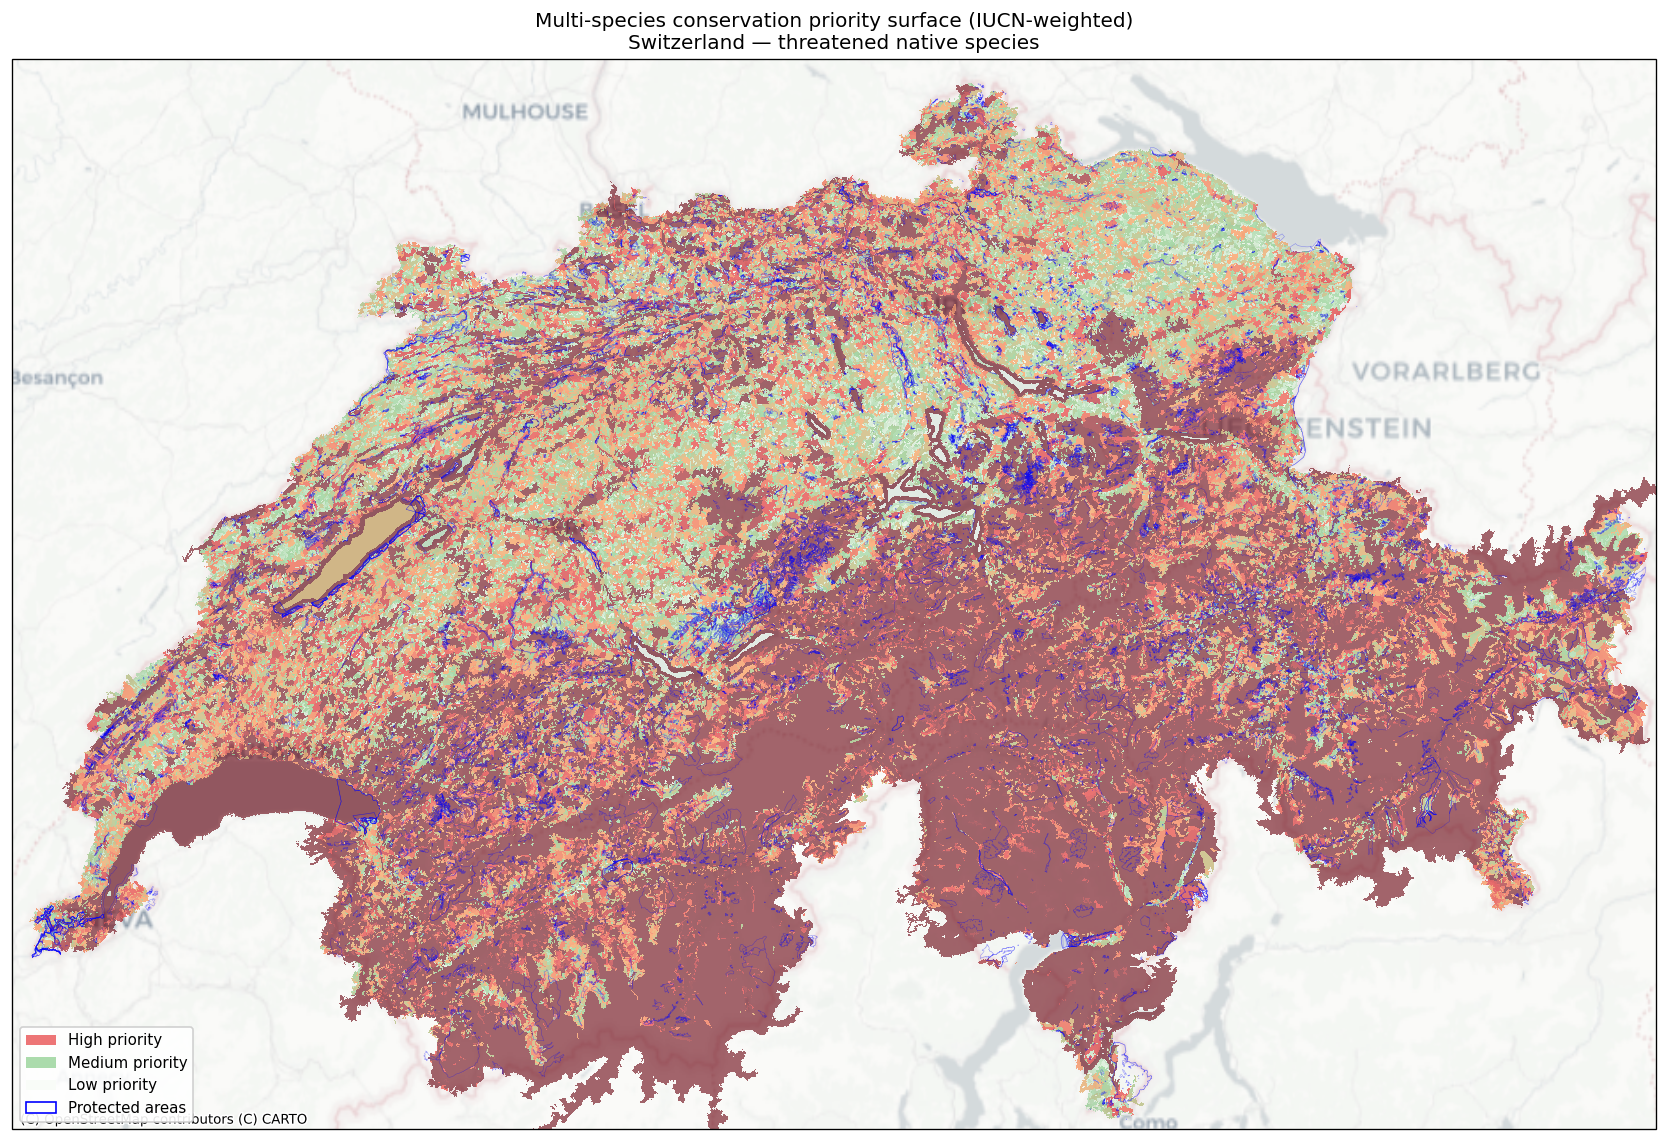

In [8]:
import numpy.ma as ma
import contextily as cx
import cartopy.crs as ccrs
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

# Switzerland extent (approx)
ch_extent = {'lon_min': 5.9, 'lon_max': 10.5, 'lat_min': 45.8, 'lat_max': 47.85}

# Map priority score onto the raster
priority_raster = np.full((h, w), np.nan, dtype=np.float32)
priority_raster[valid] = priority_score[patch_ids_flat]

# Map protection status onto the raster (2 = strict, 1 = managed/other, 0 = not)
prot_raster = np.zeros((h, w), dtype=np.float32)
protected_set_arr = np.zeros(n_patches, dtype=np.float32)
for p in strict_patches:
    protected_set_arr[p] = 2.0
for p in (protected_patches - strict_patches):
    if protected_set_arr[p] == 0:
        protected_set_arr[p] = 1.0
prot_raster[valid] = protected_set_arr[patch_ids_flat]

# Also mark Swiss boundary
swiss_set_arr = np.zeros(n_patches, dtype=np.float32)
for p in swiss_patches:
    swiss_set_arr[p] = 1.0

# Mask to Switzerland
ch_pixel_mask = np.zeros((h, w), dtype=bool)
ch_pixel_mask[valid] = swiss_set_arr[patch_ids_flat] > 0.5

priority_masked = ma.masked_where(~ch_pixel_mask | np.isnan(priority_raster), priority_raster)

# Colormaps
priority_cmap = LinearSegmentedColormap.from_list(
    'priority', ['#f7fcf5', '#74c476', '#fd8d3c', '#e31a1c', '#67000d'])

fig, ax = plt.subplots(figsize=(14, 10),
                       subplot_kw={'projection': ccrs.PlateCarree()},
                       dpi=120)
ax.set_extent([ch_extent['lon_min'], ch_extent['lon_max'],
               ch_extent['lat_min'], ch_extent['lat_max']])

cx.add_basemap(ax, crs=ccrs.PlateCarree(),
               source=cx.providers.CartoDB.Positron, zoom=8)

extent = [bounds[0], bounds[2], bounds[1], bounds[3]]

# Priority surface
p95_val = np.percentile(priority_score[priority_score > 0], 95)
ax.imshow(priority_masked, cmap=priority_cmap, vmin=0, vmax=p95_val,
          alpha=0.6, extent=extent, origin='upper',
          interpolation='nearest', transform=ccrs.PlateCarree())

# Protected area outlines
pa.boundary.plot(ax=ax, color='blue', linewidth=0.3, alpha=0.4,
                 transform=ccrs.PlateCarree())

legend_elements = [
    Patch(facecolor='#e31a1c', alpha=0.6, label='High priority'),
    Patch(facecolor='#74c476', alpha=0.6, label='Medium priority'),
    Patch(facecolor='#f7fcf5', alpha=0.6, label='Low priority'),
    Patch(facecolor='none', edgecolor='blue', linewidth=1, label='Protected areas'),
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=9, framealpha=0.9)
ax.set_title('Multi-species conservation priority surface (IUCN-weighted)\n'
             'Switzerland — threatened native species', fontsize=12)
plt.tight_layout()
plt.show()

### Map 2: Emmental region — priority + expansion candidates

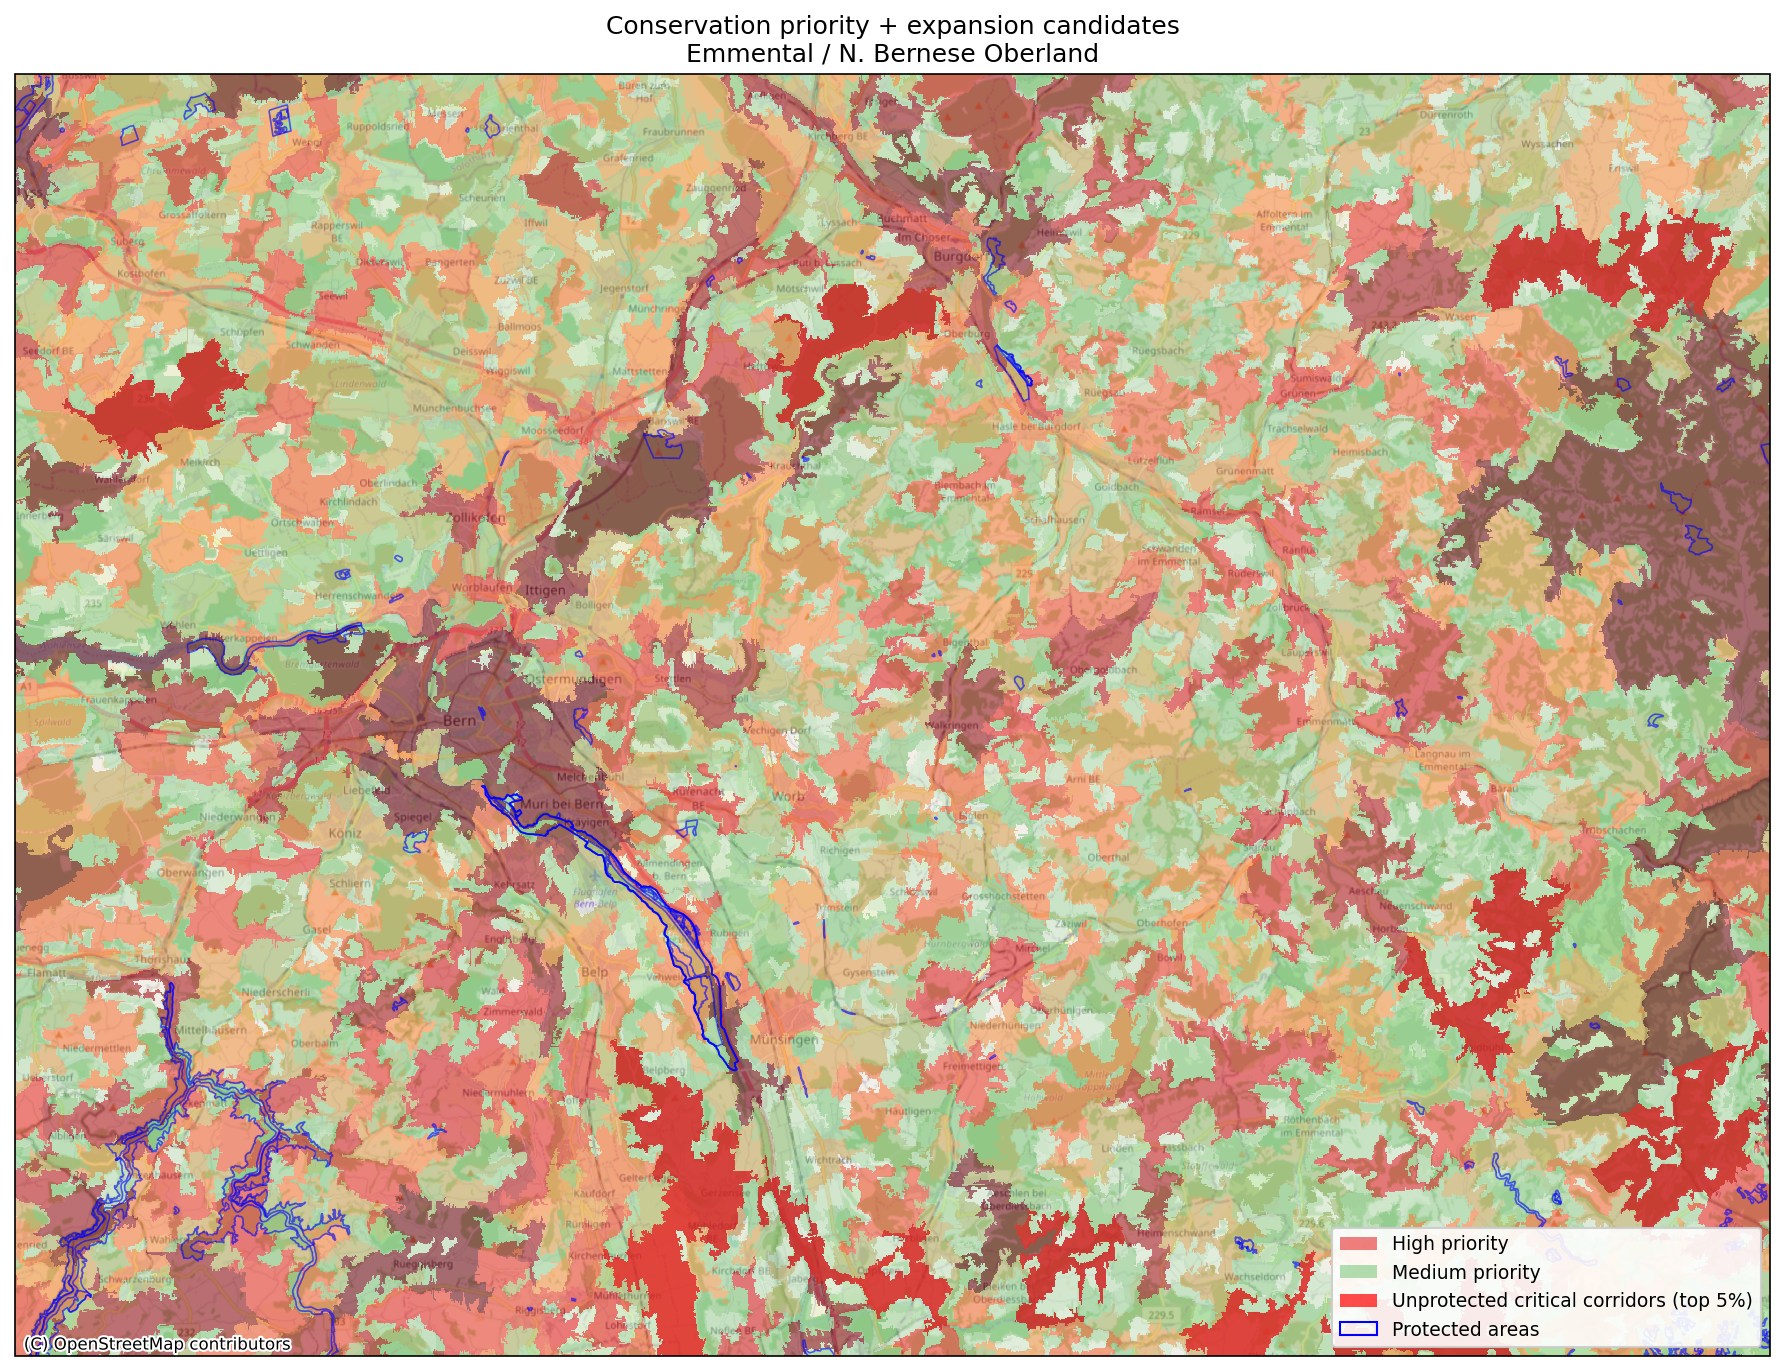

In [9]:
# Emmental / northern Bernese Oberland ROI
roi = {'lon_min': 7.3, 'lon_max': 7.9, 'lat_min': 46.8, 'lat_max': 47.1}

fig, ax = plt.subplots(figsize=(12, 10),
                       subplot_kw={'projection': ccrs.PlateCarree()},
                       dpi=150)
ax.set_extent([roi['lon_min'], roi['lon_max'],
               roi['lat_min'], roi['lat_max']])

cx.add_basemap(ax, crs=ccrs.PlateCarree(),
               source=cx.providers.OpenStreetMap.Mapnik, zoom=12)

# Clip patch labels to ROI
label_roi = patch_labels_da.sel(
    y=slice(roi['lat_max'], roi['lat_min']),
    x=slice(roi['lon_min'], roi['lon_max']),
)
labels_arr = label_roi.values
roi_valid = labels_arr >= 0
roi_extent = [roi['lon_min'], roi['lon_max'], roi['lat_min'], roi['lat_max']]

# Priority in ROI
priority_roi = np.zeros_like(labels_arr, dtype=np.float32)
priority_roi[roi_valid] = priority_score[labels_arr[roi_valid]]
priority_roi_masked = ma.masked_where(~roi_valid | (priority_roi < 0.01), priority_roi)

ax.imshow(priority_roi_masked, cmap=priority_cmap, vmin=0, vmax=p95_val,
          alpha=0.55, extent=roi_extent, origin='upper',
          interpolation='nearest', transform=ccrs.PlateCarree())

# Mark unprotected critical corridor patches (top 5%)
expansion_mask = np.zeros(n_patches, dtype=bool)
for p in cc_unprotected:
    expansion_mask[p] = True
expansion_roi = np.zeros_like(labels_arr, dtype=np.float32)
expansion_roi[roi_valid] = expansion_mask[labels_arr[roi_valid]].astype(np.float32)
expansion_roi_masked = ma.masked_where(expansion_roi < 0.5, expansion_roi)

ax.imshow(expansion_roi_masked, cmap='Reds', vmin=0, vmax=1.5,
          alpha=0.7, extent=roi_extent, origin='upper',
          interpolation='nearest', transform=ccrs.PlateCarree())

# PA outlines in ROI
pa.boundary.plot(ax=ax, color='blue', linewidth=0.8, alpha=0.6,
                 transform=ccrs.PlateCarree())

legend_elements = [
    Patch(facecolor='#e31a1c', alpha=0.55, label='High priority'),
    Patch(facecolor='#74c476', alpha=0.55, label='Medium priority'),
    Patch(facecolor='red', alpha=0.7, label='Unprotected critical corridors (top 5%)'),
    Patch(facecolor='none', edgecolor='blue', linewidth=1, label='Protected areas'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9, framealpha=0.9)
ax.set_title('Conservation priority + expansion candidates\n'
             'Emmental / N. Bernese Oberland', fontsize=12)
plt.tight_layout()
plt.show()